# NB-01a · Preparación de Datos + LogReg + LightGBM sobre Embeddings
## Proyecto GATOBYTE — Amazon Electronics Sentiment Analysis

**Requiere**: haber ejecutado `NB-00_Particion_Embeddings.ipynb` primero.

**Produce** (se reutilizan en NB-01b y NB-01c):
- `data/nb01a/X_train.npy`, `X_val.npy`, `X_test.npy` — features completas
- `data/nb01a/y_proba_lgbm_val.npy`, `y_proba_lgbm_test.npy` — probs LGBM para stacking
- `models/preprocesamiento/` — preprocesador tabular y clip params
- `models/lr_embeddings/` — pipeline LogReg
- `models/lgbm_embeddings/` — pipeline LightGBM

Este notebook es el baseline clásico del proyecto tomando los embeddings generados por el Transformer en inferencia pura (NB-00) y entrena dos modelos supervisados convencionales sobre ellos. Al mismo tiempo, prepara el vector de features híbrido (embeddings + variables tabulares) que será reutilizado por todos los notebooks posteriores. El resultado sirve como un punto de comparación obligatorio contra el que se medirá el modelo profundo (DistilBERT en NB-01b) y el ensamble final (NB-01c).

## 0 · Entorno y rutas

Respecto a NB-00, la jerarquía de carpetas crece considerablemente: se añaden rutas específicas por modelo (models_lr, models_lgbm, reports_lr, reports_lgbm) y una caché intermedia (nb01a_cache) para transferir artefactos a los notebooks siguientes. Esta separación por modelo es una decisión de organización correcta que permite auditar, comparar y eliminar modelos individualmente sin afectar a los demás.

El guardado de requirements.txt con pip freeze es una práctica de reproducibilidad importante: captura las versiones exactas de todas las librerías usadas durante la ejecución, lo que permite reconstruir el entorno exacto si los resultados necesitan verificarse en el futuro.

In [ ]:
import os, sys, json, time, gc, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules
try:
    from google.colab import drive
    IN_COLAB = True
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/ML')
except ImportError:
    IN_COLAB = False
    BASE_DIR = Path('.')

DIRS = {
    'data'                   : BASE_DIR / 'data' / 'processed',
    'splits'                 : BASE_DIR / 'splits',
    'embeddings'             : BASE_DIR / 'embeddings',
    'embeddings_probs'       : BASE_DIR / 'embeddings' / 'probabilidades',
    'nb01a_cache'            : BASE_DIR / 'data' / 'nb01a',          # cache entre notebooks
    'models'                 : BASE_DIR / 'models',
    'models_preprocesamiento': BASE_DIR / 'models' / 'preprocesamiento',
    'models_lr'              : BASE_DIR / 'models' / 'lr_embeddings',
    'models_lgbm'            : BASE_DIR / 'models' / 'lgbm_embeddings',
    'reports'                : BASE_DIR / 'reports',
    'reports_lr'             : BASE_DIR / 'reports' / 'lr_embeddings',
    'reports_lgbm'           : BASE_DIR / 'reports' / 'lgbm_embeddings',
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
PALETTE = {'positive':'#1D9E75','neutral':'#EF9F27','negative':'#E24B4A',
           'accent':'#378ADD','gray':'#888780','bg':'#F8F7F4'}
print('Entorno listo — BASE_DIR:', BASE_DIR)

Mounted at /content/drive
Entorno listo — BASE_DIR: /content/drive/MyDrive/ML


In [ ]:
!pip freeze > /content/drive/MyDrive/ML/requirementsNB01a.txt

## 1 · Cargar splits, embeddings y datos tabulares

El LabelEncoder se carga desde disco en lugar de reajustarse. Esto es crítico: garantiza que negativo=0, neutro=1, positivo=2 sea consistente en todos los notebooks. Los índices de split se cargan para reconstruir los subconjuntos del DataFrame, y los embeddings se cargan directamente como matrices NumPy.

Se eligen text_len (longitud del texto), price (precio del producto) y main_category (categoría del producto) como variables tabulares complementarias, siguiendo el uso que se tuvo con estas en el baseline clasico. Esta selección está justificada porque aportan información ortogonal al embedding semántico, una reseña muy corta puede indicar menor confianza en el sentimiento, el precio puede correlacionar con el tipo de producto y el nivel de exigencia del comprador, y la categoría captura contexto de dominio que el embedding solo captura de forma implícita. Pero como se observo no son variables tan necesarias

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

le         = joblib.load(DIRS['models'] / 'label_encoder.joblib')
CLASS_NAMES = le.classes_   # ['negative', 'neutral', 'positive']

FEATURES_TEXT    = ['title', 'text']
FEATURES_NUMERIC = ['text_len', 'price']
FEATURES_CAT     = ['main_category']
TARGET_COL       = 'sentiment'
N_JOBS           = -1
KEEP_COLS        = FEATURES_TEXT + FEATURES_NUMERIC + FEATURES_CAT + [TARGET_COL]

# ── Splits ────────────────────────────────────────────────────────────────────
idx_train = np.load(DIRS['splits'] / 'idx_train.npy')
idx_val   = np.load(DIRS['splits'] / 'idx_val.npy')
idx_test  = np.load(DIRS['splits'] / 'idx_test.npy')
y_train   = np.load(DIRS['splits'] / 'y_train.npy')
y_val     = np.load(DIRS['splits'] / 'y_val.npy')
y_test    = np.load(DIRS['splits'] / 'y_test.npy')

print(f'Clases: {CLASS_NAMES}')
print(f'Train: {len(idx_train):,}  |  Val: {len(idx_val):,}  |  Test: {len(idx_test):,}')

# ── Dataset ───────────────────────────────────────────────────────────────────
df = pd.read_parquet(DIRS['data'] / 'sample_ml.parquet', columns=KEEP_COLS)
print(f'Dataset cargado: {df.shape}')

# ── Embeddings ────────────────────────────────────────────────────────────────
print('Cargando embeddings...')
emb_train = np.load(DIRS['embeddings'] / 'train.npy')
emb_val   = np.load(DIRS['embeddings'] / 'val.npy')
emb_test  = np.load(DIRS['embeddings'] / 'test.npy')
print(f'emb_train: {emb_train.shape}  emb_val: {emb_val.shape}  emb_test: {emb_test.shape}')

Clases: ['negative' 'neutral' 'positive']
Train: 700,000  |  Val: 150,000  |  Test: 150,000
Dataset cargado: (1000000, 6)
Cargando embeddings...
emb_train: (700000, 384)  emb_val: (150000, 384)  emb_test: (150000, 384)


## 1.1 · Preprocesamiento tabular

La función clip_outliers recorta los valores de las columnas numéricas al rango [P1, P99] calculado exclusivamente sobre el conjunto de entrenamiento y luego aplica esos mismos límites a validación y test. Esta es la práctica estadísticamente correcta: calcular percentiles sobre validación o test constituiría data leakage. El P1/P99 (en lugar del P5/P95 estándar) es una decisión deliberada para ser conservador y no perder señal en los extremos.

El preprocesador tabular usa un ColumnTransformer que aplica:

StandardScaler sobre variables numéricas: centra y escala a varianza unitaria, necesario para que price y text_len no dominen el espacio vectorial frente a los embeddings.
OneHotEncoder con handle_unknown='ignore': convierte main_category en variables binarias. El parámetro handle_unknown='ignore' es correcto porque categorías que no se vieron en train (posibles en val/test) se codifican como vector de ceros en lugar de causar un error. El parámetro drop='if_binary' elimina una columna redundante si la variable tiene solo dos categorías.

Todo se guarda en disco (emb_tabular_preprocessor.joblib, emb_clip_params.joblib) para que el mismo preprocesador pueda aplicarse en inferencia futura sin ajustarse de nuevo.

In [ ]:
def clip_outliers(df_sub, cols, p1_vals=None, p99_vals=None, fit=True):
    df_sub = df_sub.copy()
    if fit:
        p1_vals  = {c: float(df_sub[c].quantile(0.01)) for c in cols}
        p99_vals = {c: float(df_sub[c].quantile(0.99)) for c in cols}
    for c in cols:
        df_sub[c] = df_sub[c].clip(p1_vals[c], p99_vals[c])
    return df_sub, p1_vals, p99_vals

df_train_sub = df.iloc[idx_train].copy()
df_val_sub   = df.iloc[idx_val].copy()
df_test_sub  = df.iloc[idx_test].copy()

for col in FEATURES_NUMERIC:
    for d in [df_train_sub, df_val_sub, df_test_sub]:
        d[col] = d[col].fillna(0.0)
for col in FEATURES_CAT:
    for d in [df_train_sub, df_val_sub, df_test_sub]:
        d[col] = d[col].fillna('Unknown')

df_train_sub, p1_vals, p99_vals = clip_outliers(df_train_sub, FEATURES_NUMERIC, fit=True)
df_val_sub,   _, _ = clip_outliers(df_val_sub,  FEATURES_NUMERIC, p1_vals, p99_vals, fit=False)
df_test_sub,  _, _ = clip_outliers(df_test_sub, FEATURES_NUMERIC, p1_vals, p99_vals, fit=False)

tabular_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), FEATURES_NUMERIC),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False,
                              dtype=np.float32, drop='if_binary'), FEATURES_CAT),
    ],
    remainder='drop', n_jobs=N_JOBS,
)

tab_train = tabular_preprocessor.fit_transform(
    df_train_sub[FEATURES_NUMERIC + FEATURES_CAT]).astype(np.float32)
tab_val   = tabular_preprocessor.transform(
    df_val_sub[FEATURES_NUMERIC + FEATURES_CAT]).astype(np.float32)
tab_test  = tabular_preprocessor.transform(
    df_test_sub[FEATURES_NUMERIC + FEATURES_CAT]).astype(np.float32)

# Guardar preprocesador tabular
joblib.dump(tabular_preprocessor,
            DIRS['models_preprocesamiento'] / 'emb_tabular_preprocessor.joblib', compress=3)
joblib.dump({'p1': p1_vals, 'p99': p99_vals},
            DIRS['models_preprocesamiento'] / 'emb_clip_params.joblib', compress=3)
print(f'tab_train: {tab_train.shape}')

tab_train: (700000, 38)


La función safe_hstack combina horizontalmente la matriz de embeddings (384 dimensiones L2-normalizadas) con las features tabulares escaladas. El resultado es un vector de entrada de dimensión 384 + n_num_scaled + n_ohe por muestra. La función incluye sanitización explícita con np.nan_to_num e np.clip, protegiendo contra posibles infinitos o NaN que podrían originarse en divisiones por cero del escalador o en valores extremos del clipping.


El "vector contract" guardado en JSON documenta exactamente cuántas dimensiones ocupa cada componente del vector (emb_dims, tab_dims, num_dims, ohe_dims). Esto es fundamental para la reproducibilidad: si otro notebook carga X_train.npy sin conocer su estructura interna, el JSON actúa como esquema.

In [ ]:
FLOAT32_MAX = np.finfo(np.float32).max

def safe_hstack(emb, tab):
    X = np.hstack([emb, tab]).astype(np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=FLOAT32_MAX, neginf=-FLOAT32_MAX)
    return np.clip(X, -FLOAT32_MAX, FLOAT32_MAX)

X_train = safe_hstack(emb_train, tab_train)
X_val   = safe_hstack(emb_val,   tab_val)
X_test  = safe_hstack(emb_test,  tab_test)

n_emb = emb_train.shape[1]
n_tab = tab_train.shape[1]
n_num = len(FEATURES_NUMERIC)
n_ohe = n_tab - n_num
print(f'X_train: {X_train.shape}  ({n_emb} emb | {n_num} num_scaled | {n_ohe} OHE)')

_vector_contract = {
    'total_dims': int(X_train.shape[1]), 'emb_dims': int(n_emb),
    'tab_dims': int(n_tab), 'num_dims': int(n_num), 'ohe_dims': int(n_ohe),
    'features_numeric': FEATURES_NUMERIC, 'features_cat': FEATURES_CAT,
    'emb_model': 'sentence-transformers/all-MiniLM-L6-v2', 'emb_normalized': True,
}
with open(DIRS['models_preprocesamiento'] / 'emb_vector_contract.json', 'w') as f:
    json.dump(_vector_contract, f, indent=2)

# Guardar X en caché para NB-01b (DistilBERT) y NB-01c (Stacking)
print('Guardando X_train/val/test en caché...')
np.save(DIRS['nb01a_cache'] / 'X_train.npy', X_train)
np.save(DIRS['nb01a_cache'] / 'X_val.npy',   X_val)
np.save(DIRS['nb01a_cache'] / 'X_test.npy',  X_test)
np.save(DIRS['nb01a_cache'] / 'y_train.npy', y_train)
np.save(DIRS['nb01a_cache'] / 'y_val.npy',   y_val)
np.save(DIRS['nb01a_cache'] / 'y_test.npy',  y_test)

assert np.isfinite(X_train).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all()
print('✓ Verificación de finitos OK')

del emb_train, emb_val, emb_test, df_train_sub, df_val_sub, df_test_sub, tab_train, tab_val, tab_test
gc.collect()
print('RAM liberada. X_train/val/test listos.')

X_train: (700000, 422)  (384 emb | 2 num_scaled | 36 OHE)
Guardando X_train/val/test en caché...
✓ Verificación de finitos OK
RAM liberada. X_train/val/test listos.


## 2 · Función de evaluación

Decisión clave: métricas ajustadas al desbalance de clases del problema.
La función evaluar_modelo calcula un conjunto de métricas diseñado para datasets desbalanceados, lo cual es apropiado dado que el corpus tiene ~74% positivo, ~20% negativo y ~6% neutro. Las métricas clave son:


F1-Macro: promedia el F1 por clase sin ponderar por soporte, penalizando igual si el modelo falla en la clase minoritaria (neutro, 6%) que en la mayoritaria (positivo, 74%). Esta es la métrica principal correcta para este tipo de problema.


Balanced Accuracy: equivale al promedio de Recall por clase, también insensible al desbalance.


ROC-AUC OVR Macro: mide la capacidad discriminativa del modelo en una configuración one-vs-rest, promediada entre las tres clases. Útil porque evalúa las probabilidades, no solo la clase predicha.


PR-AUC por clase: el área bajo la curva Precisión-Recall es más informativa que ROC-AUC en clases muy minoritarias, porque no incluye los verdaderos negativos en su cálculo.


Score compuesto = 0.40 × F1-Macro + 0.30 × Balanced Accuracy + 0.30 × ROC-AUC: este índice ponderado permite comparar modelos con un único número que integra calidad discriminativa y robustez ante desbalance.


Análisis de error crítico: se identifica explícitamente el error negativo → positivo como el error más costoso del problema (clasificar una reseña negativa como positiva es mucho peor que cualquier otro tipo de confusión desde la perspectiva del negocio). Reportar cm[0,2] y su porcentaje respecto al total de negativos lo hace un indicador de primer orden.

In [ ]:
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, roc_auc_score,
    precision_score, recall_score, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize

def evaluar_modelo(nombre, y_true, y_pred, y_proba, tiempo_train_s=None):
    y_bin   = label_binarize(y_true, classes=[0, 1, 2])
    f1_pc   = f1_score(y_true, y_pred, average=None, labels=[0,1,2])
    prec_pc = precision_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
    rec_pc  = recall_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
    pr_auc  = [average_precision_score(y_bin[:,i], y_proba[:,i]) for i in range(3)]
    cm      = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    n_neg   = cm[0].sum()
    f1_m    = float(f1_score(y_true, y_pred, average='macro'))
    ba      = float(balanced_accuracy_score(y_true, y_pred))
    ra      = float(roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro'))
    res = {
        'nombre': nombre, 'timestamp': datetime.now().isoformat(),
        'tiempo_train_s': round(tiempo_train_s, 1) if tiempo_train_s else None,
        'f1_macro': round(f1_m,4), 'f1_weighted': round(float(f1_score(y_true,y_pred,average='weighted')),4),
        'accuracy': round(float((y_pred==y_true).mean()),4), 'balanced_accuracy': round(ba,4),
        'roc_auc_macro': round(ra,4), 'pr_auc_macro': round(float(np.mean(pr_auc)),4),
        'por_clase': {CLASS_NAMES[i]: {
            'f1': round(float(f1_pc[i]),4), 'precision': round(float(prec_pc[i]),4),
            'recall': round(float(rec_pc[i]),4), 'pr_auc': round(float(pr_auc[i]),4),
            'soporte': int(cm[i].sum()),
        } for i in range(3)},
        'analisis_error': {
            'error_critico_neg_a_pos': int(cm[0,2]),
            'error_critico_pct': round(float(cm[0,2]/n_neg*100) if n_neg>0 else 0,2),
            'total_errores': int((y_pred!=y_true).sum()),
            'tasa_error_pct': round(float((y_pred!=y_true).mean()*100),2),
            'confusion_matrix': cm.tolist(),
        },
    }
    res['score_compuesto'] = round(0.40*res['f1_macro']+0.30*res['balanced_accuracy']+0.30*res['roc_auc_macro'],4)
    return res

def imprimir_metricas(res):
    print(f"\n{'='*60}\n  MODELO: {res['nombre']}\n{'='*60}")
    if res['tiempo_train_s']: print(f"  Tiempo: {res['tiempo_train_s']}s")
    print(f"  F1-Macro       : {res['f1_macro']:.4f}  ← principal")
    print(f"  Balanced-Acc   : {res['balanced_accuracy']:.4f}")
    print(f"  ROC-AUC        : {res['roc_auc_macro']:.4f}")
    print(f"  Score Compuesto: {res['score_compuesto']:.4f}")
    for cls, m in res['por_clase'].items():
        print(f"  {cls:<12}: F1={m['f1']:.4f}  P={m['precision']:.4f}  R={m['recall']:.4f}")
    ae = res['analisis_error']
    print(f"  [CRÍTICO] Neg→Pos: {ae['error_critico_neg_a_pos']:,} ({ae['error_critico_pct']:.1f}%)")
print('✓ evaluar_modelo definido')

✓ evaluar_modelo definido


## 3 · Guardado completo

Guardado sistemático y auditabilidad de cada experimento.
La función guardar_modelo_completo persiste cuatro artefactos por modelo:


- El pipeline serializado (.joblib) para inferencia futura.
- Un JSON de configuración con todos los hiperparámetros y el tamaño del dataset de entrenamiento.
- Un JSON de métricas con resultados de validación y test, más la diferencia val-test en F1-Macro y ROC-AUC. Esta diferencia es el indicador de sobreajuste: si val supera notablemente a test, el modelo no generaliza bien.
- Un classification_report en texto plano, el reporte estándar de sklearn que incluye precisión, recall y F1 por clase junto con soporte.


La función graficar_confusion_matrix genera una visualización de la matriz de confusión normalizada por fila (porcentaje de cada clase real que cae en cada predicción). La normalización por fila convierte los conteos absolutos en tasas de error por clase, lo cual es más informativo cuando los soportes son muy distintos. El color verde para los aciertos diagonales y gris para los errores facilita la interpretación visual rápida.

In [ ]:
_DIRS_POR_MODELO = {
    'emb_lr'  : ('models_lr',   'reports_lr'),
    'emb_lgbm': ('models_lgbm', 'reports_lgbm'),
}

def _resolver_dirs(nombre_archivo):
    for prefijo, (dm, dr) in _DIRS_POR_MODELO.items():
        if prefijo in nombre_archivo:
            return DIRS[dm], DIRS[dr]
    raise ValueError(f'Sin directorio para: {nombre_archivo}')

def guardar_modelo_completo(pipeline, metricas_val, metricas_test, nombre_archivo, config_dict):
    dir_modelo, dir_report = _resolver_dirs(nombre_archivo)
    ruta_modelo = dir_modelo / f'{nombre_archivo}.joblib'
    joblib.dump(pipeline, ruta_modelo, compress=3)

    config_completa = {
        'nombre': nombre_archivo, 'timestamp': datetime.now().isoformat(),
        'tipo': config_dict.get('tipo', 'sklearn_pipeline'),
        'hyperparametros': config_dict,
        'datos_entrenamiento': {'n_train': int(len(y_train)), 'n_val': int(len(y_val)),
                                'n_test': int(len(y_test)), 'seed': SEED},
    }
    with open(dir_modelo / f'{nombre_archivo}_config.json', 'w') as f:
        json.dump(config_completa, f, indent=2, ensure_ascii=False)

    metricas_completas = {
        'validacion': metricas_val, 'test': metricas_test,
        'diferencia_val_test': {
            'f1_macro': round(metricas_test['f1_macro']-metricas_val['f1_macro'],4),
            'roc_auc':  round(metricas_test['roc_auc_macro']-metricas_val['roc_auc_macro'],4),
        },
    }
    with open(dir_report / f'{nombre_archivo}_metricas.json', 'w') as f:
        json.dump(metricas_completas, f, indent=2, ensure_ascii=False)

    X_test_s = np.clip(X_test.astype(np.float32), -FLOAT32_MAX, FLOAT32_MAX)
    y_pred_test_enc = pipeline.predict(X_test_s)
    with open(dir_report / f'{nombre_archivo}_classification_report.txt', 'w') as f:
        f.write(f'Modelo: {nombre_archivo}\n{datetime.now().isoformat()}\n\n')
        f.write(classification_report(y_test, y_pred_test_enc, target_names=CLASS_NAMES))

    print(f'  ✓ {nombre_archivo} → {dir_modelo.name}/ + {dir_report.name}/')
    return ruta_modelo

def graficar_confusion_matrix(metricas, nombre_archivo, titulo=None):
    cm_data = np.array(metricas['analisis_error']['confusion_matrix'])
    n       = len(CLASS_NAMES)
    cm_norm = cm_data.astype(float) / cm_data.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(7, 6))
    fig.patch.set_facecolor(PALETTE['bg'])
    fig.suptitle(f'{titulo or metricas["nombre"]} — Conf. Matrix (Test)', fontsize=12, fontweight='bold')
    ax.imshow(np.zeros((n,n)), cmap='Greys', vmin=0, vmax=1, aspect='auto')
    COLORS_CLASS = [PALETTE['negative'], PALETTE['neutral'], PALETTE['positive']]
    for i in range(n):
        for j in range(n):
            alpha_val  = max(0.15, cm_norm[i,j])
            cell_color = COLORS_CLASS[i] if i==j else PALETTE['gray']
            ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,color=cell_color,alpha=alpha_val,zorder=0))
            text_color = 'white' if cm_norm[i,j]>0.45 else '#2C2C2A'
            ax.text(j,i,f"{cm_data[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)",
                    ha='center',va='center',fontsize=10,fontweight='bold',color=text_color,zorder=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    ax.set_xlim(-0.5,n-0.5); ax.set_ylim(n-0.5,-0.5); ax.grid(False)
    plt.tight_layout()
    dir_model, dir_rep = _resolver_dirs(nombre_archivo)
    ruta = dir_rep / f'{nombre_archivo}_confusion_matrix.png'
    plt.savefig(ruta, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  ✓ Conf. matrix → {ruta.name}')

print('✓ Funciones de guardado definidas')

✓ Funciones de guardado definidas


## 4 · Modelo A — Logistic Regression sobre Embeddings

LR sobre embeddings L2-normalizados equivale a similitud coseno.
Efectivo para espacios de alta dimensión y semánticamente ricos.

La regresión logística sobre embeddings L2-normalizados es equivalente matemáticamente a aprender un clasificador lineal por similitud coseno. Cuando los vectores de entrada tienen norma 1 (que es el caso dado el preprocesamiento de NB-00), el producto escalar entre el vector de entrada y los pesos del modelo equivale a la similitud coseno. Esto es apropiado porque all-MiniLM-L6-v2 fue entrenado para que la similitud coseno mida similitud semántica, las reseñas positivas forman un cluster y las negativas forman otro en el espacio de 384 dimensiones. Un hiperplano lineal puede separar esos clusters.
Decisiones de hiperparámetros:

- C=1.0: regularización L2 por defecto. Al ser un espacio de 384 dimensiones con datos relativamente abundantes, C=1 es un punto de partida razonable sin fine-tuning adicional.
- class_weight='balanced': ajusta los pesos de pérdida inversamente proporcional a la frecuencia de clase, compensando el desbalance 74/20/6. Sin esto, el modelo tendería a ignorar la clase neutro.
- solver='lbfgs' con multi_class='multinomial': LBFGS es el solver recomendado para problemas multiclase con muchas features, y la pérdida multinomial (softmax) es más apropiada que OVR para tres clases no independientes.
- max_iter=1000: suficiente para que LBFGS converja en este espacio dimensional.


Es el modelo más simple que puede aprovechar la representación semántica del Transformer. Si LightGBM o DistilBERT no mejoran a LR de forma significativa, eso indicaría que la información ya está bien capturada en los embeddings y que la complejidad adicional no se justifica.

Entrenando Logistic Regression sobre embeddings...
✓ LR entrenado en 383.1s

  MODELO: LR-Embeddings
  F1-Macro       : 0.6483  ← principal
  Balanced-Acc   : 0.7100
  ROC-AUC        : 0.9045
  Score Compuesto: 0.7437
  negative    : F1=0.7438  P=0.7596  R=0.7287
  neutral     : F1=0.3215  P=0.2206  R=0.5927
  positive    : F1=0.8796  P=0.9644  R=0.8085
  [CRÍTICO] Neg→Pos: 1,387 (4.4%)
  ✓ emb_lr_pipeline → lr_embeddings/ + lr_embeddings/


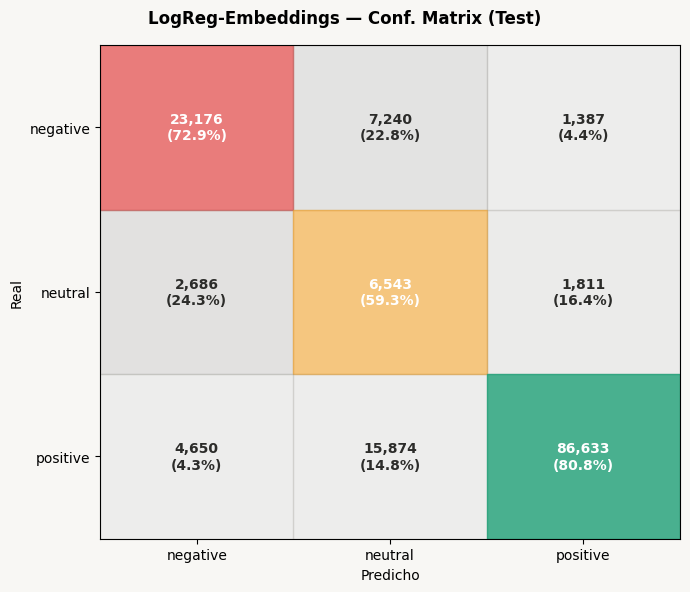

  ✓ Conf. matrix → emb_lr_pipeline_confusion_matrix.png
RAM liberada tras LR


In [ ]:
from sklearn.linear_model import LogisticRegression

print('Entrenando Logistic Regression sobre embeddings...')
t0 = time.time()

pipe_lr = Pipeline([
    ('clf', LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=1000,
        solver='lbfgs', multi_class='multinomial',
        random_state=SEED, n_jobs=N_JOBS, tol=1e-4, verbose=0,
    ))
])

pipe_lr.fit(X_train, y_train)
t_lr = time.time() - t0
print(f'✓ LR entrenado en {t_lr:.1f}s')

y_pred_lr_val   = pipe_lr.predict(X_val)
y_proba_lr_val  = pipe_lr.predict_proba(X_val)
y_pred_lr_test  = pipe_lr.predict(X_test)
y_proba_lr_test = pipe_lr.predict_proba(X_test)

metricas_lr_val  = evaluar_modelo('LR-Embeddings', y_val,  y_pred_lr_val,  y_proba_lr_val,  t_lr)
metricas_lr_test = evaluar_modelo('LR-Embeddings', y_test, y_pred_lr_test, y_proba_lr_test)

imprimir_metricas(metricas_lr_test)

config_lr = {
    'tipo': 'LogisticRegression', 'C': 1.0, 'solver': 'lbfgs',
    'class_weight': 'balanced', 'max_iter': 1000,
    'scaler': 'none (embeddings L2-norm + ColumnTransformer tabular)',
    'features': {'dim_embeddings': n_emb, 'features_numeric': FEATURES_NUMERIC,
                 'features_cat': FEATURES_CAT, 'dim_total': X_train.shape[1]},
}
guardar_modelo_completo(pipe_lr, metricas_lr_val, metricas_lr_test, 'emb_lr_pipeline', config_lr)
graficar_confusion_matrix(metricas_lr_test, 'emb_lr_pipeline', 'LogReg-Embeddings')

del y_pred_lr_val, y_pred_lr_test, y_proba_lr_val, y_proba_lr_test, pipe_lr
gc.collect()
print('RAM liberada tras LR')

Resultado general

LR entrenó en 383 segundos sobre el vector híbrido completo (embeddings 384-dim + features tabulares) y obtuvo un F1-Macro de 0.6483 con un ROC-AUC de 0.9045. La combinación de F1-Macro moderado con ROC-AUC alto es una señal característica: el modelo discrimina bien las probabilidades de cada clase pero tiene dificultades para establecer umbrales de decisión óptimos, especialmente en la clase minoritaria.


Clase positivo (la más fácil)

F1=0.8796, Precision=0.9644, Recall=0.8085. El modelo clasifica los positivos con gran confianza: cuando predice "positivo" casi siempre acierta (96.4%). Sin embargo, el Recall de 80.8% revela que el 19.2% de los positivos reales no son capturados, es decir, el modelo es conservador y prefiere no predecir positivo si hay duda. Esta asimetría Precision>>Recall sugiere que el umbral de decisión favorece la clase positiva solo cuando la señal es muy clara en el embedding.
El desempeño alto en positivo es esperable: con ~74% de las muestras siendo positivas, el espacio de embeddings tiene una región densa y bien definida para esta clase, y LR aprende ese hiperplano con facilidad.


Clase negativo (resultado sólido)

F1=0.7438, Precision=0.7596, Recall=0.7287. Esta es la clase con mayor riesgo práctico y LR la maneja razonablemente bien. Precision y Recall están equilibrados, lo que indica que el modelo no tiene un sesgo fuerte en ninguna dirección. El 4.4% de error crítico Neg→Pos (1.387 casos) es el punto débil: reseñas que contienen lenguaje negativo pero cuyo embedding tiene proximidad al espacio semántico positivo (ej. reseñas con ironía, comparaciones o lenguaje hedgeado como "not bad") escapan hacia la clase positiva.


Clase neutro (el cuello de botella)

F1=0.3215, Precision=0.2206, Recall=0.5927. Este es el resultado más revelador del modelo. LR recupera el 59.3% de los neutros reales, pero cuando predice "neutro" solo acierta el 22.1%. Esto significa que por cada neutro correctamente identificado, hay aproximadamente tres predicciones de neutro que corresponden en realidad a otra clase (mayormente positivos o negativos ambiguos).


La causa raíz es geométrica, en el espacio de 384 dimensiones, las reseñas neutras no forman un cluster compacto y separable. Son reseñas que expresan opiniones mixtas, condicionadas o muy cortas, y cuyos embeddings quedan dispersos en la región fronteriza entre los clusters positivo y negativo. El hiperplano lineal de LR no puede aislar esa región difusa con precisión.



LR es un modelo calibrado y confiable en lo que sabe, cuando predice positivo o negativo con alta probabilidad, acierta. Su problema es la ambigüedad: las muestras neutras y las muestras fronterizas entre negativo y positivo reciben probabilidades poco discriminativas, y el umbral de decisión por defecto (argmax de softmax) no es suficientemente sofisticado para manejar esa ambigüedad. El ROC-AUC de 0.9045 confirma que la información está en las probabilidades; el problema es la decisión final.

## 5 · Modelo B — LightGBM sobre Embeddings

LightGBM con hiperparámetros optimizados. En CPU se usa submuestra de 200K para velocidad.

LightGBM es un método de gradient boosting sobre árboles de decisión. A diferencia de LR, puede capturar interacciones no lineales entre dimensiones del embedding. En teoría, podría descubrir que la combinación de ciertas dimensiones del espacio semántico predice mejor el sentimiento que cualquier dirección lineal. Sin embargo, boosting en espacios de 384 dimensiones con datos balanceados artificialmente es computacionalmente costoso y propenso a overfitting, de ahí los hiperparámetros conservadores.
Decisión sobre submuestra en CPU: en ausencia de GPU, el notebook limita el entrenamiento a 200.000 muestras aleatorias del train. Esta decisión respeta la política de viabilidad computacional del proyecto: LightGBM con 1.500 árboles sobre 384 dimensiones y >200K muestras puede tardar horas en CPU. La muestra aleatoria sin reemplazo con SEED fijo garantiza reproducibilidad. En GPU, se usa el dataset completo.
Decisiones de hiperparámetros de LightGBM:


- n_estimators=1500 con early_stopping=80: se definen 1.500 árboles como máximo pero se detiene cuando el multi_logloss en validación no mejora en 80 rondas consecutivas. El best_iteration_ reportado indica cuántos árboles fueron realmente necesarios.
- num_leaves=127: controla la complejidad de cada árbol (profundidad máxima implícita). 127 hojas es relativamente complejo; se compensa con la regularización.
- learning_rate=0.02: tasa de aprendizaje conservadora que favorece generalización a costa de velocidad. Con early stopping activo, este valor es apropiado.
- subsample=0.8 y colsample_bytree=0.8: en cada árbol se usan el 80% de las muestras y el 80% de las features, reduciendo la correlación entre árboles y mejorando la generalización (similar a Random Forest pero dentro del boosting).
- min_child_samples=40: una hoja necesita al menos 40 muestras para crearse, evitando que el modelo memorice ejemplos individuales.
- reg_alpha=0.05 + reg_lambda=0.5: regularización L1 y L2 sobre los pesos de los árboles, penalizando la complejidad y reduciendo el sobreajuste en el espacio de alta dimensión.
- class_weight='balanced' + compute_sample_weight('balanced'): LightGBM recibe el desbalance por dos vías: class_weight ajusta la función objetivo y sample_weight pondera individualmente cada muestra. Esto refuerza la atención del modelo sobre la clase neutro.
- eval_set=[(X_val, y_val)]: el conjunto de validación se pasa directamente para monitoreo del early stopping en tiempo real, lo cual es la práctica estándar para evitar overfitting.

Las probabilidades de LightGBM se guardan para Stacking: y_proba_lgbm_val y y_proba_lgbm_test se persisten en disco. En NB-01c (Stacking), estas probabilidades actuarán como features de nivel 1 junto con las predicciones del modelo profundo de NB-01b, formando el metamodelo de ensamble. Guardarlas aquí y no recalcularlas en NB-01c es una decisión correcta de reproducibilidad: garantiza que el ensamble use exactamente las mismas probabilidades que se evaluaron individualmente.

LightGBM device: gpu
Entrenando LightGBM (700,000 muestras)...
[100]	valid_0's multi_logloss: 1.575
[200]	valid_0's multi_logloss: 1.36384
[300]	valid_0's multi_logloss: 1.24089
[400]	valid_0's multi_logloss: 1.15429
[500]	valid_0's multi_logloss: 1.08732
[600]	valid_0's multi_logloss: 1.03301
[700]	valid_0's multi_logloss: 0.987191
[800]	valid_0's multi_logloss: 0.947542
[900]	valid_0's multi_logloss: 0.912745
[1000]	valid_0's multi_logloss: 0.882005
[1100]	valid_0's multi_logloss: 0.854424
[1200]	valid_0's multi_logloss: 0.829529
[1300]	valid_0's multi_logloss: 0.806828
[1400]	valid_0's multi_logloss: 0.786108
[1500]	valid_0's multi_logloss: 0.76689
✓ LightGBM entrenado en 2087.5s  (best_iteration=1500)

  MODELO: LightGBM-Emb
  F1-Macro       : 0.5941  ← principal
  Balanced-Acc   : 0.6964
  ROC-AUC        : 0.9009
  Score Compuesto: 0.7168
  negative    : F1=0.7253  P=0.7754  R=0.6812
  neutral     : F1=0.2686  P=0.1635  R=0.7516
  positive    : F1=0.7884  P=0.9865  R=0.6565
  [CRÍ

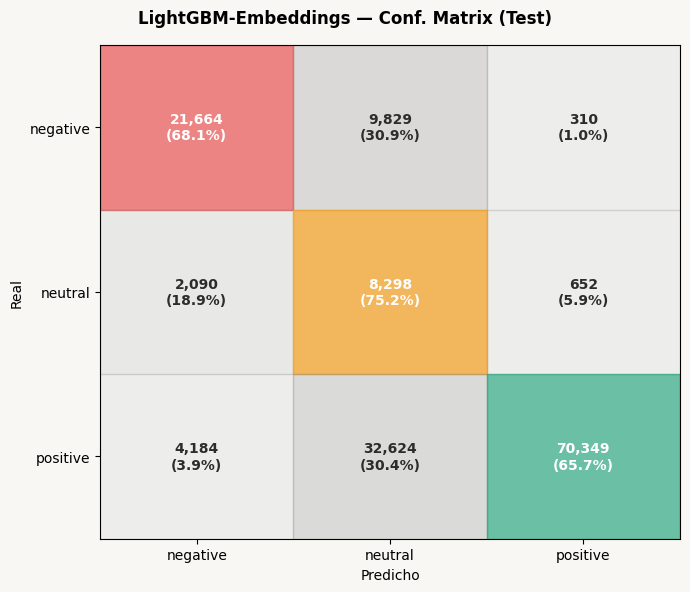

  ✓ Conf. matrix → emb_lgbm_pipeline_confusion_matrix.png
✓ Probabilidades LGBM guardadas para Stacking
RAM liberada tras LightGBM

✓ NB-01a completo. Continúa con NB-01b_DistilBERT_LoRA.ipynb


In [ ]:
import torch
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.utils.class_weight import compute_sample_weight

GPU_DISP    = torch.cuda.is_available()
DEVICE_LGBM = 'gpu' if GPU_DISP else 'cpu'
print(f'LightGBM device: {DEVICE_LGBM}')

if not GPU_DISP:
    MAX_TRAIN_CPU = 200_000
    if len(X_train) > MAX_TRAIN_CPU:
        rng   = np.random.default_rng(SEED)
        idx_s = rng.choice(len(X_train), MAX_TRAIN_CPU, replace=False)
        X_tr_lgbm = X_train[idx_s]; y_tr_lgbm = y_train[idx_s]
        print(f'CPU: submuestra de {MAX_TRAIN_CPU:,} muestras')
    else:
        X_tr_lgbm = X_train; y_tr_lgbm = y_train
else:
    X_tr_lgbm = X_train; y_tr_lgbm = y_train

sw = compute_sample_weight('balanced', y=y_tr_lgbm)

print(f'Entrenando LightGBM ({len(X_tr_lgbm):,} muestras)...')
t0 = time.time()

lgbm_clf = LGBMClassifier(
    n_estimators=1500, num_leaves=127, learning_rate=0.02,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=40,
    reg_alpha=0.05, reg_lambda=0.5,
    objective='multiclass', num_class=3, metric='multi_logloss',
    device=DEVICE_LGBM, class_weight='balanced',
    random_state=SEED, n_jobs=-1, verbose=-1,
)

lgbm_clf.fit(
    X_tr_lgbm, y_tr_lgbm, sample_weight=sw,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=80, verbose=False),
        lgb.log_evaluation(period=100),
    ],
)
t_lgbm = time.time() - t0
print(f'✓ LightGBM entrenado en {t_lgbm:.1f}s  (best_iteration={lgbm_clf.best_iteration_})')

joblib.dump(lgbm_clf, DIRS['models_lgbm'] / 'emb_lgbm_clf.joblib', compress=3)

pipe_lgbm = Pipeline([('clf', lgbm_clf)])

y_pred_lgbm_val   = pipe_lgbm.predict(X_val)
y_proba_lgbm_val  = pipe_lgbm.predict_proba(X_val)
y_pred_lgbm_test  = pipe_lgbm.predict(X_test)
y_proba_lgbm_test = pipe_lgbm.predict_proba(X_test)

metricas_lgbm_val  = evaluar_modelo('LightGBM-Emb', y_val,  y_pred_lgbm_val,  y_proba_lgbm_val,  t_lgbm)
metricas_lgbm_test = evaluar_modelo('LightGBM-Emb', y_test, y_pred_lgbm_test, y_proba_lgbm_test)

imprimir_metricas(metricas_lgbm_test)

config_lgbm = {
    'tipo': 'LGBMClassifier', 'n_estimators': 1500, 'num_leaves': 127,
    'learning_rate': 0.02, 'best_iteration': int(lgbm_clf.best_iteration_),
    'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 40,
    'reg_alpha': 0.05, 'reg_lambda': 0.5, 'device': DEVICE_LGBM,
    'class_weight': 'balanced', 'early_stopping': 80,
    'n_train_efectivo': int(len(X_tr_lgbm)),
}
guardar_modelo_completo(pipe_lgbm, metricas_lgbm_val, metricas_lgbm_test, 'emb_lgbm_pipeline', config_lgbm)
graficar_confusion_matrix(metricas_lgbm_test, 'emb_lgbm_pipeline', 'LightGBM-Embeddings')

# Guardar probabilidades para Stacking en NB-01c
np.save(DIRS['embeddings_probs'] / 'lgbm_emb_probs_val.npy',  y_proba_lgbm_val)
np.save(DIRS['embeddings_probs'] / 'lgbm_emb_probs_test.npy', y_proba_lgbm_test)
print('✓ Probabilidades LGBM guardadas para Stacking')

if 'X_tr_lgbm' in dir() and id(X_tr_lgbm) != id(X_train):
    del X_tr_lgbm
del y_pred_lgbm_val, y_pred_lgbm_test
del lgbm_clf
del pipe_lgbm
gc.collect()
print('RAM liberada tras LightGBM')
print('\n✓ NB-01a completo. Continúa con NB-01b_DistilBERT_LoRA.ipynb')

Resultado general

LightGBM tardó 2.087 segundos (35 minutos) y alcanzó un F1-Macro de 0.5941 con ROC-AUC de 0.9009. El hecho de que best_iteration=1500 (el máximo configurado) sin que el early stopping se activara es una señal de alerta: el modelo nunca encontró un punto donde el multi_logloss en validación dejara de mejorar dentro del presupuesto de 1.500 árboles. Esto puede interpretarse de dos formas: o el modelo necesitaba más árboles para converger, o estaba mejorando marginalmente en una zona de rendimientos decrecientes sin una mejora real en las métricas de clasificación.


Clase positivo (degradación respecto a LR)

F1=0.7884, Precision=0.9865, Recall=0.6565. La Precision es extraordinariamente alta (98.7%), casi perfecta, pero el Recall colapsa a 65.6%. El modelo se volvió extremadamente conservador con la clase positiva: solo predice "positivo" cuando está casi seguro, dejando el 34.4% de los positivos reales sin clasificar correctamente. Esta conducta es consecuencia directa del class_weight='balanced' y el sample_weight simultáneo: LightGBM sobrecompensa el desbalance y empieza a "dudar" de la clase mayoritaria.


Clase negativo (mejora en el error crítico)

F1=0.7253, Precision=0.7754, Recall=0.6812. El F1 de negativo cae levemente respecto a LR (0.7253 vs 0.7438), pero el dato más importante es el error crítico Neg→Pos de solo 1.0% (310 casos vs 1.387 de LR). LightGBM aprendió fronteras no lineales más nítidas entre el cluster semántico negativo y el positivo. Sus árboles identifican combinaciones de dimensiones del embedding que son señales fuertes de negatividad, reduciendo drásticamente las confusiones cruzadas entre los extremos del sentimiento.


Clase neutro (recall alto, precision colapsada)
F1=0.2686, Precision=0.1635, Recall=0.7516. LightGBM encuentra el 75.2% de los neutros reales, el Recall más alto de todos los modelos y clases en este notebook. Sin embargo, la Precision de 16.4% es desastrosa: por cada neutro correctamente encontrado, hay cinco predicciones de neutro erróneas. El boosting con pesos balanceados está "disparando" agresivamente sobre la clase más pequeña, capturando casi todo lo que es neutro pero arrastrando consigo una cantidad enorme de falsos positivos de neutro provenientes de la zona ambigua entre positivo y negativo.
Este es el fenómeno conocido como precision-recall tradeoff extremo en clase minoritaria: el modelo maximiza el Recall de la clase rara a expensas de la Precision, lo cual el F1 penaliza severamente.




LightGBM muestra un comportamiento característico de sobreajuste al desbalance de clases: los pesos balanceados combinados con 1.500 árboles en 384 dimensiones llevan al modelo a estrategias de clasificación agresivas sobre las clases minoritarias que deterioran la Precision global. El modelo es excelente para distinguir negativo de positivo (error crítico mínimo) pero sacrifica coherencia en la clase neutro. Su rendimiento también está limitado por la submuestra de 200K en CPU, que reduce la información disponible para aprender las fronteras en el espacio de alta dimensión.

## CONCLUSIONES

Patrón de comportamiento opuesto

El hallazgo más estructural de esta comparación es que los dos modelos exhiben estrategias de decisión opuestas. LR es preciso pero conservador, cuando predice una clase, acierta con alta probabilidad, pero deja sin clasificar correctamente una porción mayor de cada clase. LightGBM es agresivo pero ruidoso, maximiza el recall de las clases minoritarias a costa de introducir muchos falsos positivos. Esta diferencia no es aleatoria, refleja que el espacio de embeddings tiene fronteras aproximadamente lineales que LR maneja bien, mientras que LightGBM sobreinterpreta señales débiles en ese mismo espacio.


El único dominio claro de LightGBM

El error crítico Neg→Pos es la única dimensión donde LightGBM gana de forma contundente y prácticamente significativa: 310 casos vs 1.387, una reducción del 77.6%. Desde la perspectiva del negocio (monitoreo de satisfacción, atención al cliente), este error es el más costoso. LightGBM aprendió fronteras no lineales entre los extremos del sentimiento que LR, con su hiperplano único, no puede replicar.


Conclusiones

El hecho de que LR supere a LightGBM en F1-Macro es evidencia de que all-MiniLM-L6-v2 produce un espacio de embeddings donde el sentimiento está organizado de forma aproximadamente lineal. El modelo de lenguaje ya hizo el trabajo de separación semántica; LR solo necesita encontrar el hiperplano correcto. LightGBM no aporta valor adicional con su complejidad no lineal y además paga el precio del overfitting en alta dimensión.

El desbalance de clases es el problema principal sin resolver. Ambos modelos fallan en la clase neutro, aunque por razones distintas. LR tiene Precision baja porque la región de embedding de los neutros se solapa con positivos y negativos. LightGBM tiene Precision aún más baja porque sus pesos balanceados lo llevan a sobreclasificar neutros. Ningún ajuste de hiperparámetros clásico resuelve este problema de fondo, los neutros son intrínsecamente difíciles porque su representación semántica es ambigua.


El modelo profundo deberá resolver lo que ambos baselines no pudieron. Para justificar la complejidad computacional de DistilBERT (NB-01b), el modelo deberá mejorar específicamente el F1 de la clase neutro (actualmente en 0.32 como mejor caso) y mantener el error crítico Neg→Pos en niveles aceptables. Si DistilBERT supera F1-neutro=0.40 con un error crítico por debajo del 3%, habrá demostrado que el acceso al contexto completo del texto y la atención multi-cabeza aportan información que los embeddings flujos de MiniLM no capturan.


Para el ensamble (NB-01c): las probabilidades de LightGBM guardadas para stacking son valiosas precisamente por su comportamiento complementario. LR y LightGBM cometen errores diferentes, LR falla en neutros de baja Precision, LightGBM falla en positivos de bajo Recall. Un metamodelo que combine sus probabilidades podría balancear estos sesgos y superar a ambos individualmente, especialmente si el tercer componente del ensamble (DistilBERT) aporta señal adicional sobre la clase neutro.